# Exploratory Data Analysis — Customer Churn

## Overview

This notebook performs exploratory data analysis (EDA) on the cleaned customer churn dataset. The objective is to investigate patterns and relationships between customer characteristics, behaviour, service usage, and churn.

The analysis focuses on identifying potential factors associated with customer churn and generating insights that can support customer retention strategies. Findings from this analysis will also help guide feature engineering and machine learning model development in later stages of the project.

## Key Questions

This exploratory analysis aims to investigate the following questions:

1. **Which customer segments have the highest churn rates?**
2. **At what stage of the customer lifecycle is churn risk highest?**
3. **Do customer satisfaction and service friction indicate churn risk?**
4. **Is customer disengagement associated with higher churn?**
5. **Does perceived customer value influence churn?**
6. **Are certain services associated with higher customer retention?**
7. **Do payment and billing behaviours indicate churn risk?**
8. **Which types of factors are most strongly associated with churn?**
   
## Analysis Approach

For each research question, relevant customer features will be analysed and visualised to identify meaningful patterns and differences between churned and retained customers.

The analysis will follow the general structure:

**Business Question → Data Analysis → Visualisation → Key Finding**

The key findings from the EDA will be summarised at the end of the notebook and used to inform subsequent feature engineering, predictive modelling, and customer retention recommendations.

## Dataset

The dataset used in this notebook is the cleaned version produced during the data preparation stage of the project.

It contains approximately **1,000,000 telecommunications customer records** and includes information relating to:

- Customer demographics
- Account and contract characteristics
- Service subscriptions and usage
- Customer satisfaction and complaints
- Customer engagement
- Payment behaviour
- Financial characteristics
- Customer churn outcome

The target variable is **`churn`**, where:

- **0** = Customer retained
- **1** = Customer churned

### Previously found findings:
-  **No duplicate records** were identified, and **all customer IDs were unique**, indicating each row represents a distinct customer.
- Missing values were successfully handled earlier, with remaining variables containing complete records.
- Numerical variables were within realistic ranges, with no obvious invalid values detected.
- Categorical variables contained consistent labels with no duplicate category representations.
- The target variable (**churn**) is **imbalanced**, with approximately **90.1% of customers retained and 9.9% of customers churning**. Model evaluation should therefore focus on metrics beyond accuracy, such as precision, recall, F1-score, and ROC-AUC.
- We will evaluate the model's ability to identify customers who actually churned by focusing on *recall*. 
- Some variables, such as **monthlycharges**, contain **potential outliers** (mean 85.5 and max 855) that will be further investigated during exploratory data analysis.

In [14]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df = pd.read_csv("customer_churn_cleaned.csv")

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (1000000, 31)


,signup_date,age,gender,annual_income,education,marital_status,dependents,tenure,contract,payment_method,...,has_streaming_tv,has_streaming_movies,customer_satisfaction,num_complaints,num_service_calls,late_payments,avg_monthly_gb,days_since_last_interaction,credit_score,churn
0,2022-12-12 12:53:58.199463,43,Female,55085.25,college,married,1,2,two_year,electronic_check,...,1,1,9.0,0.0,0,0,109.63,16,680.0,0
1,2022-01-13 12:53:58.199973,18,Male,60786.11,master,married,1,22,one_year,bank_transfer,...,0,1,7.0,0.0,3,1,63.25,134,585.0,0
2,2023-09-04 12:53:58.199985,38,Female,73184.32,high_school,widowed,0,3,two_year,credit_card,...,1,0,6.0,1.0,1,0,47.77,11,632.0,0
3,2022-06-27 12:53:58.199992,44,Male,40923.78,high_school,married,1,6,two_year,bank_transfer,...,0,1,5.0,2.0,2,1,50.82,6,569.0,0
4,2022-12-08 12:53:58.199999,45,Female,36400.94,bachelor,single,0,9,two_year,credit_card,...,0,1,8.0,1.0,1,0,16.74,18,657.0,0


# Exploratory Analysis

## 1. Which Customer Segments Have the Highest Churn Rates?

The first stage of the analysis investigates whether churn rates differ across customer segments. Understanding which groups of customers experience higher churn may help identify high-risk customer profiles and support more targeted retention strategies.

The analysis will consider factors including:

- Contract type
- Customer demographics

### 1.1 Contract Type

Table 1: Churn Rate by Contract Type


,count,mean,churn_rate
contract,,,
month_to_month,19992,0.265056,26.505602
one_year,550468,0.126531,12.653052
two_year,429540,0.056519,5.651860


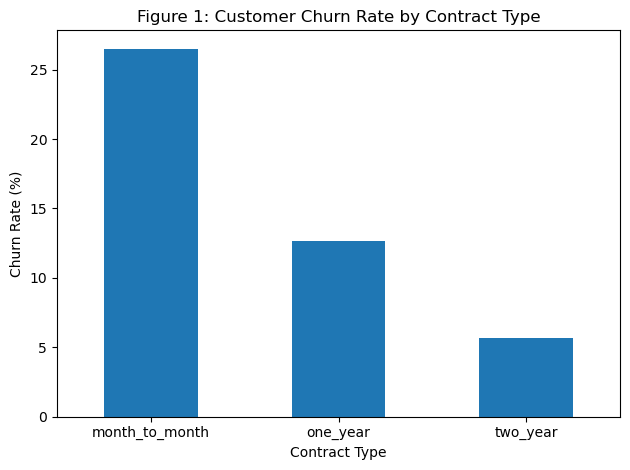

In [16]:
# Calculate churn rate by contract type
contract_churn = (
    df.groupby("contract")["churn"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

contract_churn["churn_rate"] = contract_churn["mean"] * 100


# Table 1: Churn Rate by Contract Type
print("Table 1: Churn Rate by Contract Type")
display(contract_churn)


# Figure 1: Customer Churn Rate by Contract Type
contract_churn["churn_rate"].plot(kind="bar")

plt.title("Figure 1: Customer Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Finding

Customers on month-to-month contracts had the highest churn rate at approximately 26.5%, compared with 12.7% for one-year contracts and 5.7% for two-year contracts.

This suggests that customers with shorter-term commitments represent a higher-risk customer segment and may benefit from targeted retention strategies.

---

### 1.2 Customer Demographics

This section investigates whether customer demographic characteristics are associated with differences in churn rates. The analysis considers age, gender, annual income, education level, and marital status to determine whether particular demographic groups are more likely to churn.

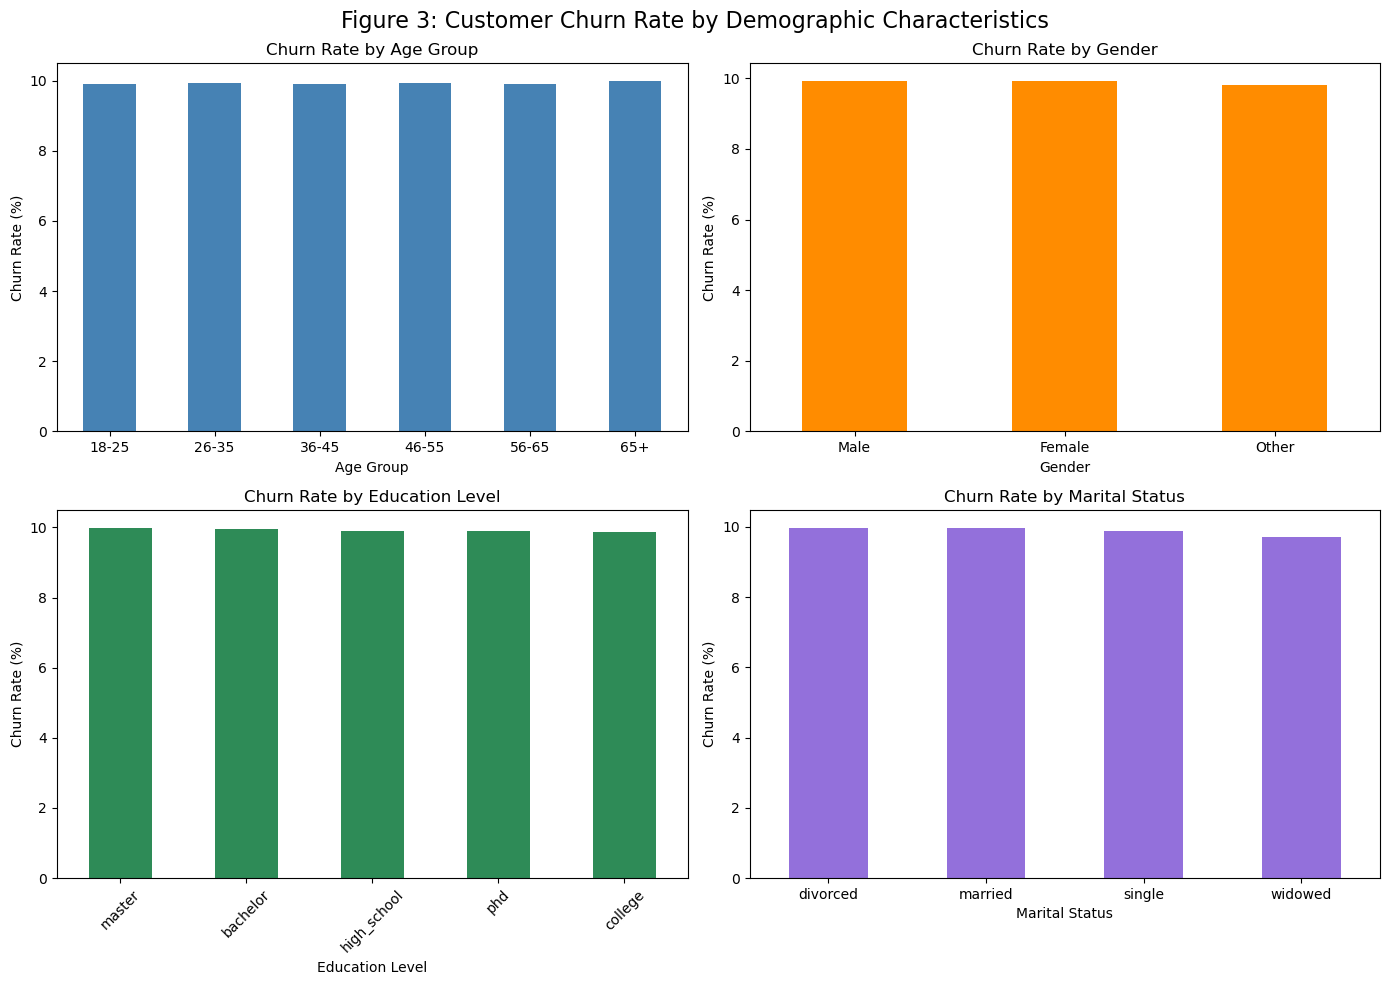

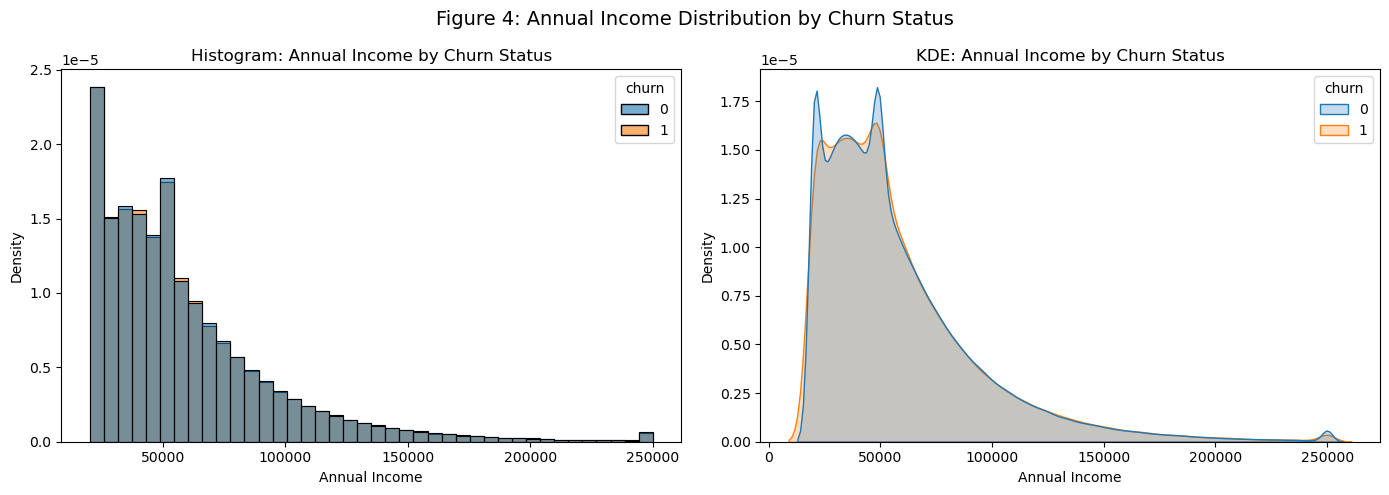

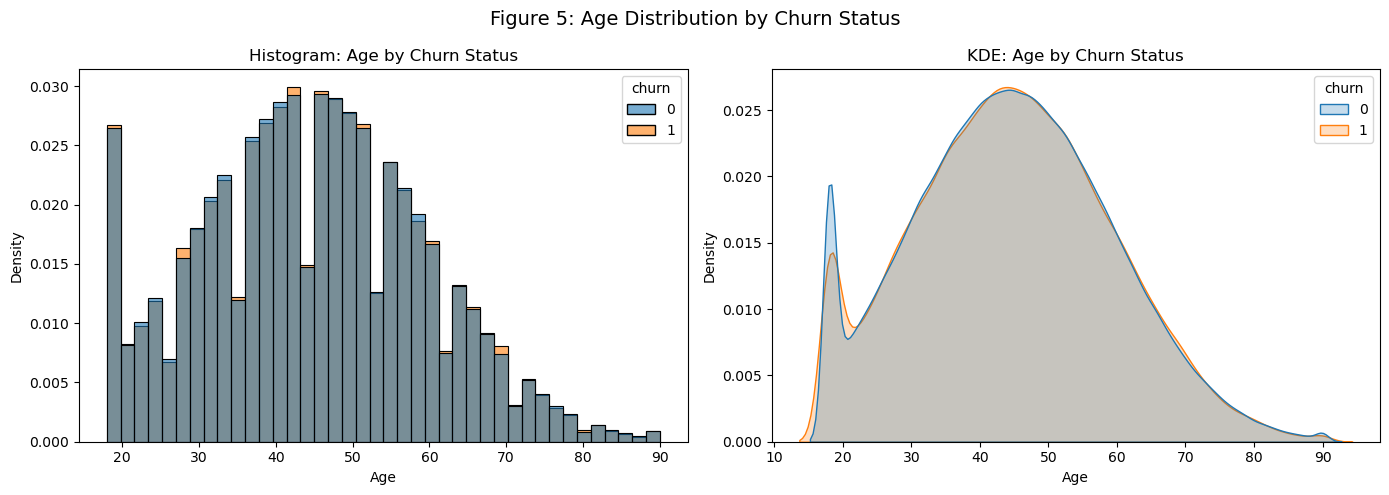


--- Demographic Churn Rate Summary ---

Age Group (%)
age_group
18-25    9.90
26-35    9.92
36-45    9.91
46-55    9.94
56-65    9.90
65+      9.99

Gender (%)
gender
Male      9.93
Female    9.92
Other     9.82

Education (%)
education
master         10.00
bachelor        9.95
high_school     9.91
phd             9.91
college         9.86

Marital Status (%)
marital_status
divorced    9.98
married     9.96
single      9.88
widowed     9.70

Annual Income by Churn Status
           mean   median
churn                   
0      58488.09  48954.6
1      58544.70  48954.6


In [17]:
# ---------------------------------------------------------
# Age Analysis
# ---------------------------------------------------------
age_bins = [0, 25, 35, 45, 55, 65, df["age"].max()]
age_labels = ["18-25", "26-35", "36-45", "46-55", "56-65", "65+"]

df["age_group"] = pd.cut(
    df["age"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

age_churn = df.groupby(
    "age_group", observed=False
)["churn"].agg(["count", "mean"])

age_churn["churn_rate"] = age_churn["mean"] * 100


# ---------------------------------------------------------
# Gender Analysis
# ---------------------------------------------------------
gender_churn = (
    df.groupby("gender")["churn"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

gender_churn["churn_rate"] = gender_churn["mean"] * 100


# ---------------------------------------------------------
# Education Analysis
# ---------------------------------------------------------
education_churn = (
    df.groupby("education")["churn"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

education_churn["churn_rate"] = education_churn["mean"] * 100


# ---------------------------------------------------------
# Marital Status Analysis
# ---------------------------------------------------------
marital_churn = (
    df.groupby("marital_status")["churn"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

marital_churn["churn_rate"] = marital_churn["mean"] * 100


# ---------------------------------------------------------
# Annual Income Analysis
# ---------------------------------------------------------
income_churn = (
    df.groupby("churn")["annual_income"]
    .agg(["count", "mean", "median"])
)


# ---------------------------------------------------------
# Figure 3: Demographic Churn Rates
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

age_churn["churn_rate"].plot(
    kind="bar", ax=axes[0, 0], color="steelblue", width=0.5
)
axes[0, 0].set_title("Churn Rate by Age Group")
axes[0, 0].set_xlabel("Age Group")
axes[0, 0].set_ylabel("Churn Rate (%)")
axes[0, 0].tick_params(axis="x", rotation=0)

gender_churn["churn_rate"].plot(
    kind="bar", ax=axes[0, 1], color="darkorange", width=0.5
)
axes[0, 1].set_title("Churn Rate by Gender")
axes[0, 1].set_xlabel("Gender")
axes[0, 1].set_ylabel("Churn Rate (%)")
axes[0, 1].tick_params(axis="x", rotation=0)

education_churn["churn_rate"].plot(
    kind="bar", ax=axes[1, 0], color="seagreen", width=0.5
)
axes[1, 0].set_title("Churn Rate by Education Level")
axes[1, 0].set_xlabel("Education Level")
axes[1, 0].set_ylabel("Churn Rate (%)")
axes[1, 0].tick_params(axis="x", rotation=45)

marital_churn["churn_rate"].plot(
    kind="bar", ax=axes[1, 1], color="mediumpurple", width=0.5
)
axes[1, 1].set_title("Churn Rate by Marital Status")
axes[1, 1].set_xlabel("Marital Status")
axes[1, 1].set_ylabel("Churn Rate (%)")
axes[1, 1].tick_params(axis="x", rotation=0)

plt.suptitle(
    "Figure 3: Customer Churn Rate by Demographic Characteristics",
    fontsize=16
)

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# Figures 4-5: Normalized Demographic Distributions
# ---------------------------------------------------------
features = [
    ("annual_income", "Annual Income", "Figure 4"),
    ("age", "Age", "Figure 5")
]

for feature, label, figure in features:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.histplot(
        data=df,
        x=feature,
        hue="churn",
        bins=40,
        stat="density",
        common_norm=False,
        alpha=0.6,
        ax=axes[0]
    )

    axes[0].set_title(f"Histogram: {label} by Churn Status")
    axes[0].set_xlabel(label)
    axes[0].set_ylabel("Density")

    sns.kdeplot(
        data=df,
        x=feature,
        hue="churn",
        fill=True,
        common_norm=False,
        ax=axes[1]
    )

    axes[1].set_title(f"KDE: {label} by Churn Status")
    axes[1].set_xlabel(label)
    axes[1].set_ylabel("Density")

    plt.suptitle(
        f"{figure}: {label} Distribution by Churn Status",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------
# Summary Statistics
# ---------------------------------------------------------
print("\n--- Demographic Churn Rate Summary ---")

print("\nAge Group (%)")
print(age_churn["churn_rate"].round(2).to_string())

print("\nGender (%)")
print(gender_churn["churn_rate"].round(2).to_string())

print("\nEducation (%)")
print(education_churn["churn_rate"].round(2).to_string())

print("\nMarital Status (%)")
print(marital_churn["churn_rate"].round(2).to_string())

print("\nAnnual Income by Churn Status")
print(income_churn[["mean", "median"]].round(2).to_string())

### Key Findings

Across the demographic characteristics examined, churn rates remained highly consistent across all customer groups. Age groups recorded churn rates between approximately **9.90% and 9.99%**, while gender, education level, and marital status also showed only minor variation around the overall churn rate of approximately **9.9%**.

Annual income showed a similarly limited difference between churned and retained customers. Retained customers had a mean annual income of approximately **$58,488**, compared with **$58,545** for churned customers, while both groups had the same median income of approximately **$48,955**. The normalised age and annual income distributions also showed substantial overlap between churned and retained customers.

Overall, the results suggest that the demographic characteristics examined have a relatively weak association with customer churn when considered individually. From a business perspective, demographic-based targeting alone is therefore unlikely to effectively identify customers at higher risk of churn. Further analysis will investigate whether account characteristics, service usage, and customer behaviour provide clearer indicators of churn and more actionable opportunities for customer retention.

## 2. At what stage of the customer lifecycle is churn risk highest?

This section investigates whether churn risk varies across different stages of the customer lifecycle. Understanding when customers are most likely to churn may help businesses identify periods where retention efforts and customer engagement strategies could be most effective.

The analysis will consider:

- Customer tenure
- Churn rates across different tenure groups
- Average and median tenure of churned and retained customers

The analysis aims to determine whether newer customers are more vulnerable to churn and whether churn risk changes as customers develop longer relationships with the company.

### 2.1 Churn Across Customer Lifecycle Stages

Customer tenure was grouped into lifecycle stages to examine whether churn rates differ between newer and longer-term customers.

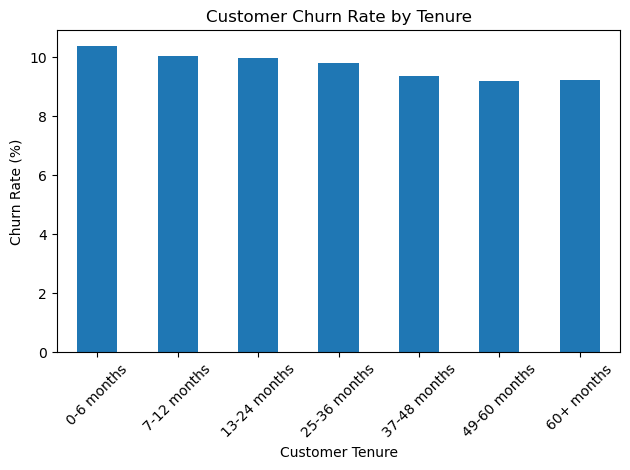


Churn Rate by Tenure Group (%)
tenure_group
0-6 months      10.39
7-12 months     10.05
13-24 months     9.99
25-36 months     9.80
37-48 months     9.37
49-60 months     9.19
60+ months       9.23


In [18]:
# Create tenure groups
tenure_bins = [0, 6, 12, 24, 36, 48, 60, df["tenure"].max()]
tenure_labels = [
    "0-6 months",
    "7-12 months",
    "13-24 months",
    "25-36 months",
    "37-48 months",
    "49-60 months",
    "60+ months"
]

df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=tenure_bins,
    labels=tenure_labels,
    include_lowest=True
)

# Calculate churn rate by tenure group
tenure_churn = (
    df.groupby("tenure_group", observed=False)["churn"]
    .agg(["count", "mean"])
)

tenure_churn["churn_rate"] = tenure_churn["mean"] * 100



# Visualise churn rate by tenure group
tenure_churn["churn_rate"].plot(kind="bar")

plt.title("Customer Churn Rate by Tenure")
plt.xlabel("Customer Tenure")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


print("\nChurn Rate by Tenure Group (%)")
print(tenure_churn["churn_rate"].round(2).to_string())

#### Finding
Customer churn shows a much **weaker relationship** than contract type. Customers in their first **0–6 months** had the highest churn rate at approximately **10.4%**, while customers with **more than four years** of tenure had churn rates of around **9.2%**.

The difference is relatively small compared with the variation observed across contract types. Churned customers also had a slightly lower average tenure (**21.6 months**) than retained customers (**22.5 months**).

This suggests that **newer customers may be slightly more likely to churn**, but tenure alone does not appear to strongly distinguish churned from retained customers. Further modelling will be needed to determine whether tenure becomes more informative when considered alongside other customer characteristics.

---

### 2.3 Tenure of Churned and Retained Customers

Finally, the overall tenure distributions of churned and retained customers were compared to determine whether customers who churn tend to have shorter relationships with the company.

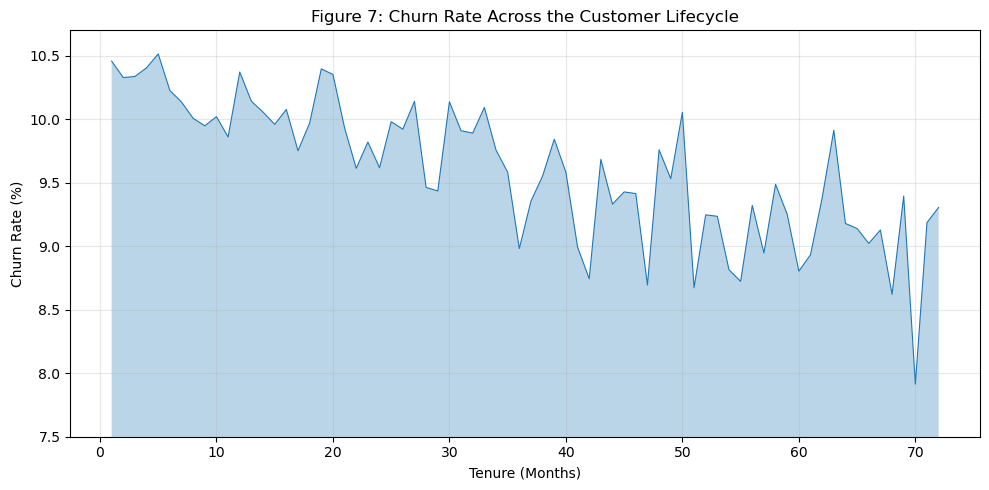

In [19]:
# Figure 7: Churn Rate Across Customer Lifecycle
tenure_monthly_churn = df.groupby("tenure")["churn"].mean() * 100

plt.figure(figsize=(10, 5))

plt.fill_between(
    tenure_monthly_churn.index,
    6,
    tenure_monthly_churn.values,
    alpha=0.3
)

plt.plot(
    tenure_monthly_churn.index,
    tenure_monthly_churn.values,
    linewidth=0.8
)

plt.title("Figure 7: Churn Rate Across the Customer Lifecycle")
plt.xlabel("Tenure (Months)")
plt.ylabel("Churn Rate (%)")
plt.ylim(7.5, 10.7)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2.3 Tenure of Churned and Retained Customers

Finally, the overall tenure distributions of churned and retained customers were compared to determine whether customers who churn tend to have shorter relationships with the company.

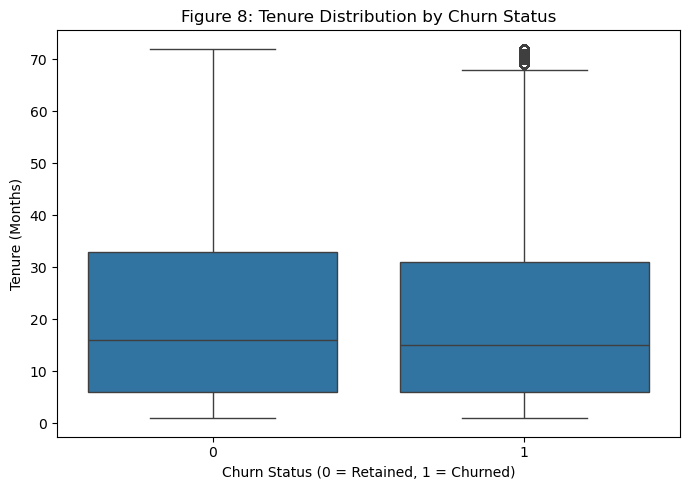


Tenure by Churn Status
        mean  median
churn               
0      22.47    16.0
1      21.61    15.0


In [20]:

# Figure 8: Tenure Distribution by Churn Status
plt.figure(figsize=(7, 5))

sns.boxplot(data=df, x="churn", y="tenure")

plt.title("Figure 8: Tenure Distribution by Churn Status")
plt.xlabel("Churn Status (0 = Retained, 1 = Churned)")
plt.ylabel("Tenure (Months)")
plt.tight_layout()
plt.show()

# Create the comparison table
tenure_comparison = (
    df.groupby("churn")["tenure"]
    .agg(["count", "mean", "median"])
)
print("\nTenure by Churn Status")
print(tenure_comparison[["mean", "median"]].round(2).to_string())

#### Key Finding

The analysis indicates that churn risk is slightly higher during the earlier stages of the customer lifecycle and generally decreases as customer tenure increases. Customers in their first **0–6 months** recorded the highest grouped churn rate at approximately **10.4%**, compared with approximately **9.2%** among customers with more than four years of tenure.

The month-by-month lifecycle analysis shows a similar overall pattern, with churn rates generally higher during the earlier months of the customer relationship and gradually declining across longer tenure periods, although some month-to-month variation is present.

The tenure distribution also shows that churned customers have a slightly shorter average tenure (**21.6 months**) than retained customers (**22.5 months**), with median tenure of **15 months** and **16 months**, respectively.

Overall, tenure has a measurable but relatively modest relationship with churn. From a business perspective, the early customer lifecycle may represent a slightly higher-risk period, suggesting that stronger onboarding and early customer engagement could support retention. However, the relatively small differences indicate that tenure alone is unlikely to be sufficient for identifying high-risk customers and should be considered alongside other behavioural and account-related factors.

In [21]:
# Inspect Q3 variables
print("Customer Satisfaction")
print(df["customer_satisfaction"].value_counts().sort_index())

print("\nNumber of Complaints")
print(df["num_complaints"].value_counts().sort_index())

print("\nNumber of Service Calls")
print(df["num_service_calls"].value_counts().sort_index())

Customer Satisfaction
customer_satisfaction
1.0     39270
2.0     49262
3.0     68647
4.0     88057
5.0    107603
6.0    127536
7.0    166613
8.0    166732
9.0    186280
Name: count, dtype: int64

Number of Complaints
num_complaints
0.0    481239
1.0    366725
2.0    118816
3.0     27537
4.0      4907
5.0       675
6.0        89
7.0        12
Name: count, dtype: int64

Number of Service Calls
num_service_calls
0     204894
1     297131
2     236336
3     140000
4      70295
5      30885
6      12650
7       4990
8       1823
9        674
10       218
11        68
12        36
Name: count, dtype: int64


## 3. How do customer satisfaction and service friction relate to churn?

This section investigates whether customer satisfaction and negative service experiences are associated with customer churn. Understanding these relationships may help identify service-related warning signs that businesses could use to detect at-risk customers and intervene before they leave.

The analysis will consider:

- Customer satisfaction levels
- Number of customer complaints
- Number of service calls

The analysis aims to determine whether lower satisfaction and increased service friction are associated with higher churn rates, and whether there are identifiable thresholds where churn risk increases.


### 3.1 Customer Satisfaction and Churn

Churn rates are compared across customer satisfaction scores from 1 to 9 to determine whether lower satisfaction is associated with an increased likelihood of churn.

A line plot is used to examine the overall relationship and identify whether churn risk changes consistently or increases sharply below a particular satisfaction level.



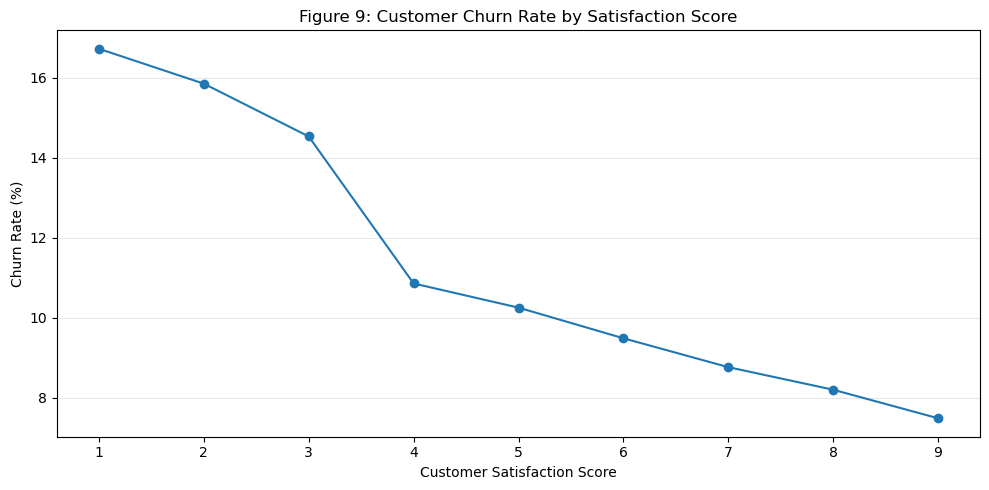


Churn Rate by Satisfaction Score (%)
customer_satisfaction
1.0    16.72
2.0    15.85
3.0    14.53
4.0    10.85
5.0    10.25
6.0     9.48
7.0     8.76
8.0     8.20
9.0     7.48


In [22]:
# Calculate churn rate by satisfaction score
satisfaction_churn = (
    df.groupby("customer_satisfaction")["churn"]
    .agg(["count", "mean"])
)

satisfaction_churn["churn_rate"] = satisfaction_churn["mean"] * 100

# Figure 9: Churn Rate by Customer Satisfaction Score
plt.figure(figsize=(10, 5))

plt.plot(
    satisfaction_churn.index,
    satisfaction_churn["churn_rate"],
    marker="o",
    linewidth=1.5
)

plt.title("Figure 9: Customer Churn Rate by Satisfaction Score")
plt.xlabel("Customer Satisfaction Score")
plt.ylabel("Churn Rate (%)")
plt.xticks(satisfaction_churn.index)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("\nChurn Rate by Satisfaction Score (%)")
print(satisfaction_churn["churn_rate"].round(2).to_string())

#### Finding

Customer satisfaction shows a clear negative relationship with churn. Customers with the lowest satisfaction score of **1** recorded a churn rate of approximately **16.7%**, compared with only **7.5%** among customers with the highest satisfaction score of **9**.

Churn rates generally decrease as customer satisfaction increases, with a particularly noticeable decline between satisfaction scores of **3 (14.5%)** and **4 (10.9%)**. This suggests that low customer satisfaction may be an important warning sign of elevated churn risk, particularly among customers with satisfaction scores of **3 or below**.

### 3.2 Customer Complaints and Churn

The relationship between customer complaints and churn is examined to determine whether customers who experience repeated issues are more likely to leave.

Due to the relatively small number of customers recording very high complaint counts, complaint levels will be grouped into:

- 0 complaints
- 1 complaint
- 2 complaints
- 3 complaints
- 4+ complaints

Churn rates will be compared across these groups to identify whether repeated complaints may act as an early warning signal for customer churn.


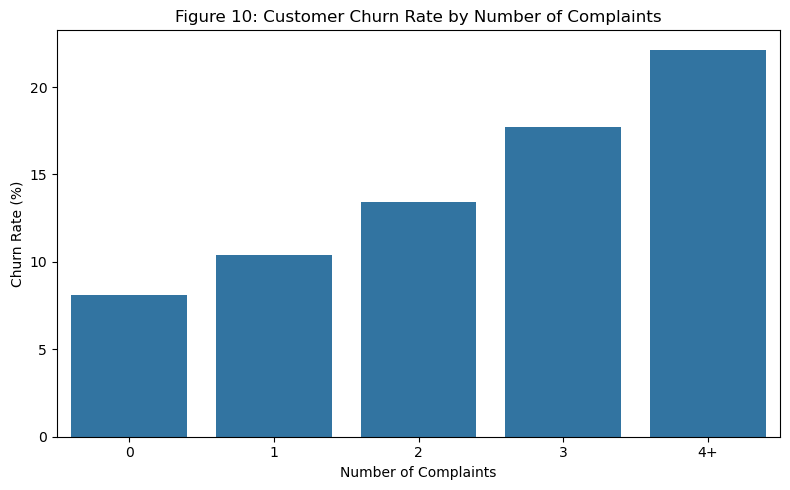


Churn Rate by Complaint Group (%)
                  count  churn_rate
complaint_group                    
0                481239        8.10
1                366725       10.42
2                118816       13.40
3                 27537       17.69
4+                 5683       22.14


In [23]:
# Group complaint counts
df["complaint_group"] = pd.cut(
    df["num_complaints"],
    bins=[-1, 0, 1, 2, 3, df["num_complaints"].max()],
    labels=["0", "1", "2", "3", "4+"]
)

complaint_churn = (
    df.groupby("complaint_group", observed=False)["churn"]
    .agg(["count", "mean"])
)

complaint_churn["churn_rate"] = complaint_churn["mean"] * 100

# Figure 10: Churn Rate by Number of Complaints
plt.figure(figsize=(8, 5))

sns.barplot(
    x=complaint_churn.index,
    y=complaint_churn["churn_rate"].values
)

plt.title("Figure 10: Customer Churn Rate by Number of Complaints")
plt.xlabel("Number of Complaints")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.show()

print("\nChurn Rate by Complaint Group (%)")
print(complaint_churn[["count", "churn_rate"]].round(2).to_string())

#### Finding

Customer churn increases consistently with the number of complaints recorded. Customers with no complaints had a churn rate of approximately **8.1%**, increasing to **10.4%** after one complaint, **13.4%** after two complaints, and **17.7%** after three complaints. Customers with four or more complaints recorded the highest churn rate at approximately **22.1%**.

This clear upward trend suggests that repeated complaints are strongly associated with increased churn risk. From a business perspective, customers making multiple complaints could be prioritised for proactive service recovery and retention efforts before further issues occur.

### 3.3 Service Calls and Churn

Churn rates are examined across the number of customer service calls to determine whether repeated contact with customer service is associated with higher churn.

The analysis will initially examine individual service-call counts to identify the overall trend and determine whether a particular number of calls represents a potential threshold for increased churn risk.


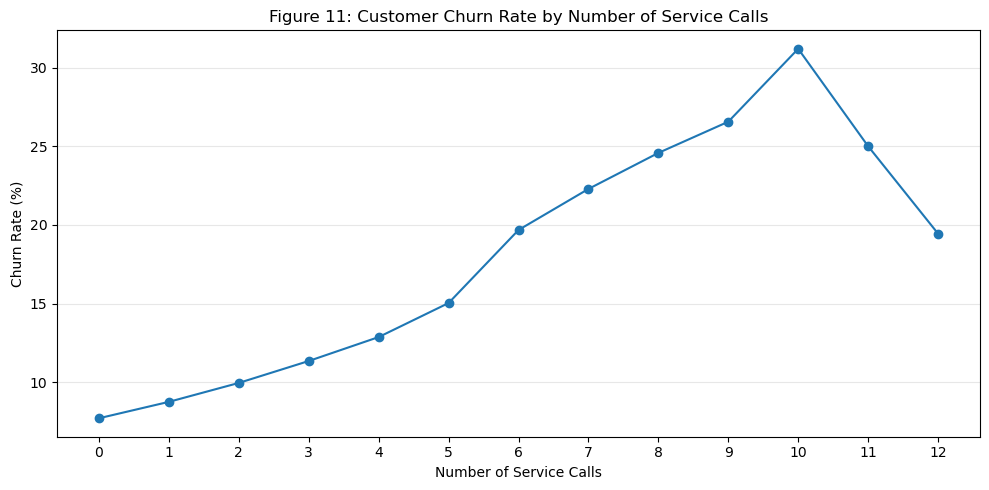


Churn Rate by Number of Service Calls (%)
                    count  churn_rate
num_service_calls                    
0                  204894        7.71
1                  297131        8.75
2                  236336        9.95
3                  140000       11.35
4                   70295       12.87
5                   30885       15.03
6                   12650       19.68
7                    4990       22.28
8                    1823       24.57
9                     674       26.56
10                    218       31.19
11                     68       25.00
12                     36       19.44


In [24]:
# Calculate churn rate by number of service calls
service_call_churn = (
    df.groupby("num_service_calls")["churn"]
    .agg(["count", "mean"])
)

service_call_churn["churn_rate"] = service_call_churn["mean"] * 100

# Figure 11: Churn Rate by Number of Service Calls
plt.figure(figsize=(10, 5))

plt.plot(
    service_call_churn.index,
    service_call_churn["churn_rate"],
    marker="o",
    linewidth=1.5
)

plt.title("Figure 11: Customer Churn Rate by Number of Service Calls")
plt.xlabel("Number of Service Calls")
plt.ylabel("Churn Rate (%)")
plt.xticks(service_call_churn.index)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("\nChurn Rate by Number of Service Calls (%)")
print(service_call_churn[["count", "churn_rate"]].round(2).to_string())

#### Finding

Churn rates generally increase as the number of customer service calls rises. Customers with no service calls recorded a churn rate of approximately **7.7%**, compared with **12.9%** among customers making four calls and **19.7%** among those making six calls. Churn continued to increase among customers with seven or more calls, reaching approximately **31.2%** at ten service calls.

The decline observed at 11 and 12 calls should be interpreted cautiously due to the very small number of customers in these groups. Overall, the results indicate that repeated service calls are associated with substantially higher churn rates, with the pattern becoming particularly pronounced from approximately **five to six service calls onwards**. This may provide businesses with a useful trigger for proactive customer intervention.

### Q3 Key Finding

Customer satisfaction and service friction show substantially clearer relationships with churn than the demographic and tenure characteristics examined earlier. Lower satisfaction scores, repeated complaints, and increasing numbers of service calls are all associated with progressively higher churn rates.

The results also identify potential warning points for customer retention efforts, particularly **satisfaction scores of 3 or below**, **multiple customer complaints**, and approximately **five or more service calls**. These factors may provide useful signals for identifying customers experiencing persistent service issues and prioritising proactive retention interventions.

These findings represent associations rather than evidence of causation. Their predictive importance will be evaluated later during machine learning modelling and model interpretation.

## 4. Are there signs of customer disengagement associated with churn?

This section investigates whether signs of reduced customer engagement are associated with customer churn. Understanding these relationships may help identify behavioural warning signs that businesses could use to detect customers who are becoming disengaged and potentially at greater risk of leaving.

The analysis will consider:

- Days since the customer's last interaction
- Average monthly data usage

The analysis aims to determine whether customers with longer periods since their last interaction or lower levels of service usage experience higher churn rates, and whether these behaviours may provide useful indicators of customer disengagement.

### 4.1 Time Since Last Interaction and Churn

The distribution of days since the customer's last interaction is compared between churned and retained customers to determine whether customers who have gone longer without interacting with the company are more likely to leave.

A normalized histogram with KDE curves is used to compare the two groups while accounting for the difference in the number of churned and retained customers.

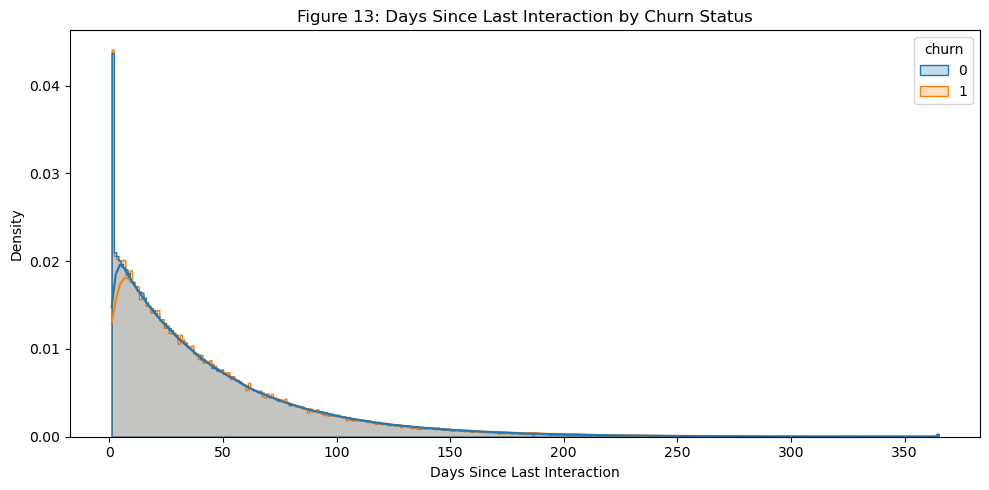


Days Since Last Interaction by Churn Status
        count   mean  median
churn                       
0      900773  44.49    31.0
1       99227  44.55    31.0


In [25]:
# Figure 13: Distribution of Days Since Last Interaction by Churn Status
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="days_since_last_interaction",
    hue="churn",
    stat="density",
    common_norm=False,
    kde=True,
    element="step"
)

plt.title("Figure 13: Days Since Last Interaction by Churn Status")
plt.xlabel("Days Since Last Interaction")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

# Numerical summary
interaction_summary = (
    df.groupby("churn")["days_since_last_interaction"]
    .agg(["count", "mean", "median"])
)

print("\nDays Since Last Interaction by Churn Status")
print(interaction_summary.round(2).to_string())

#### Finding

Days since last interaction shows no meaningful difference between churned and retained customers. Both groups recorded almost identical mean values of approximately **44.5 days** and the same median of **31 days**.

A concentration of customers at exactly **1 day since their last interaction**, representing approximately **4.4% of records**, was investigated separately. These customers had a similar tenure distribution and churn rate to the wider customer population, suggesting that the concentration does not represent a meaningful behavioural churn signal.

Overall, the time since a customer's last interaction does not appear to be a useful standalone indicator of churn risk in this dataset.

### 4.2 Monthly Data Usage and Churn

The distribution of average monthly data usage is compared between churned and retained customers to determine whether customers with lower levels of service usage are more likely to churn.

A normalized histogram with KDE curves is used to compare the two groups while accounting for the difference in the number of churned and retained customers.

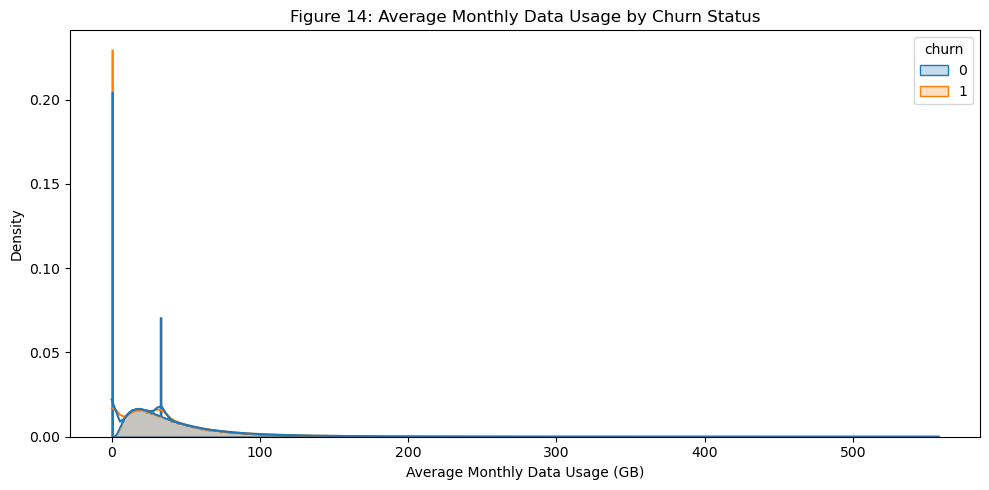


Average Monthly Data Usage by Churn Status
        count   mean  median
churn                       
0      900773  38.64   29.09
1       99227  37.75   28.37


In [69]:
# Figure 14: Distribution of Average Monthly Data Usage by Churn Status
plt.figure(figsize=(10, 5))
sns.histplot(
    data=df,
    x="avg_monthly_gb",
    hue="churn",
    stat="density",
    common_norm=False,
    kde=True,
    element="step"
)
plt.title("Figure 14: Average Monthly Data Usage by Churn Status")
plt.xlabel("Average Monthly Data Usage (GB)")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

# Numerical summary
usage_summary = (
    df.groupby("churn")["avg_monthly_gb"]
    .agg(["count", "mean", "median"])
)
print("\nAverage Monthly Data Usage by Churn Status")
print(usage_summary.round(2).to_string())

> **Methodology Note:** `avg_monthly_gb` originally contained approximately **5% missing values**. These values were initially imputed using the overall median. However, because monthly data usage is strongly influenced by whether a customer subscribes to internet service, the imputation approach was refined using group-based median values based on `has_internet_service`. The figures and summary statistics below reflect this updated imputation method.

#### Finding

Average monthly data usage shows two noticeable concentrations in its distribution. A large group of customers recorded **0 GB** of monthly usage, primarily reflecting customers without an internet service subscription. A second concentration reflects values introduced through the imputation of missing usage records.

After accounting for these structural features, churned and retained customers show only a small difference in monthly usage. Retained customers recorded a mean usage of approximately **38.64 GB** and a median of **29.09 GB**, compared with a mean of **37.75 GB** and a median of **28.37 GB** among churned customers.

Although this difference could potentially be statistically significant because of the dataset's large sample size, the difference is small in practical terms. Average monthly data usage therefore does not appear to be a strong standalone indicator of churn risk.

### 4.3 Combined Customer Disengagement

Days since the customer's last interaction and average monthly data usage are examined together to determine whether customers displaying multiple signs of reduced engagement are more likely to churn.

A sampled scatter plot is used to examine whether churned customers cluster among those with longer interaction gaps and lower levels of data usage.

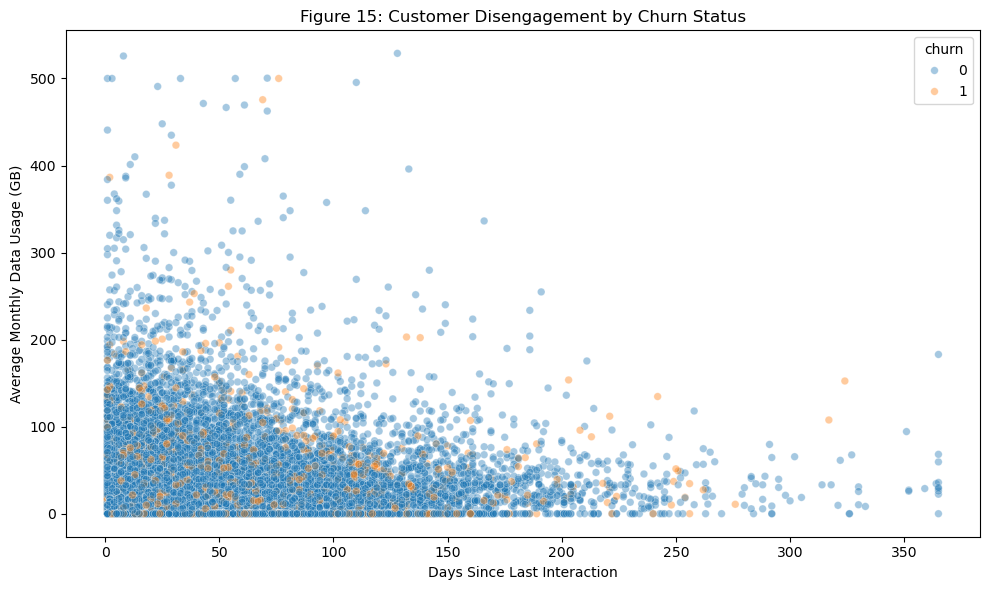

In [70]:
# ---------------------------------------------------------
# 4.3 Combined Customer Disengagement
# ---------------------------------------------------------
# Sample data for visualization (full dataset would be overplotted/unreadable)
scatter_sample = df.sample(
    n=min(20000, len(df)),
    random_state=42
)

# Figure 15: Customer Disengagement by Churn Status
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=scatter_sample,
    x="days_since_last_interaction",
    y="avg_monthly_gb",
    hue="churn",
    alpha=0.4,
    s=30
)
plt.title("Figure 15: Customer Disengagement by Churn Status")
plt.xlabel("Days Since Last Interaction")
plt.ylabel("Average Monthly Data Usage (GB)")
plt.tight_layout()
plt.show()

### Q4 Key Finding

Neither **days since last interaction** nor **average monthly data usage** showed a meaningful association with churn. Although both variables exhibited noticeable structural characteristics within their distributions, churned and retained customers displayed very similar patterns overall.

This suggests that customer disengagement, as measured by these two variables, is not a strong standalone indicator of churn risk in this dataset. This contrasts with the clearer relationships observed for factors such as **contract type**, **customer satisfaction**, and **complaint-related variables**, which appear to have a stronger association with customer churn.

## 5. Does the relationship between price and customer value influence churn?
This section investigates whether pricing, relative to the value a customer receives, is associated with churn. Rather than looking at price alone, this section builds on the usage findings from Section 4 to examine whether customers who pay more while receiving comparatively less (fewer services, lower usage) show elevated churn risk.
The analysis will consider:
- Monthly charges
- Total charges
- An engineered price-per-service measure
- The relationship between price and usage together

The analysis aims to determine whether customer perceptions of value for money — rather than price in isolation — may influence retention.

### 5.1 Monthly Charges and Churn

Monthly charges are compared between churned and retained customers to determine whether customers paying higher monthly fees are more likely to churn.

A normalized histogram with KDE curves is used to compare the distributions while accounting for the difference in the number of churned and retained customers.

Table 9: Monthly Charges by Churn Status


,count,mean,median
churn,,,
0,900773,86.57,85.57
1,99227,85.29,84.72


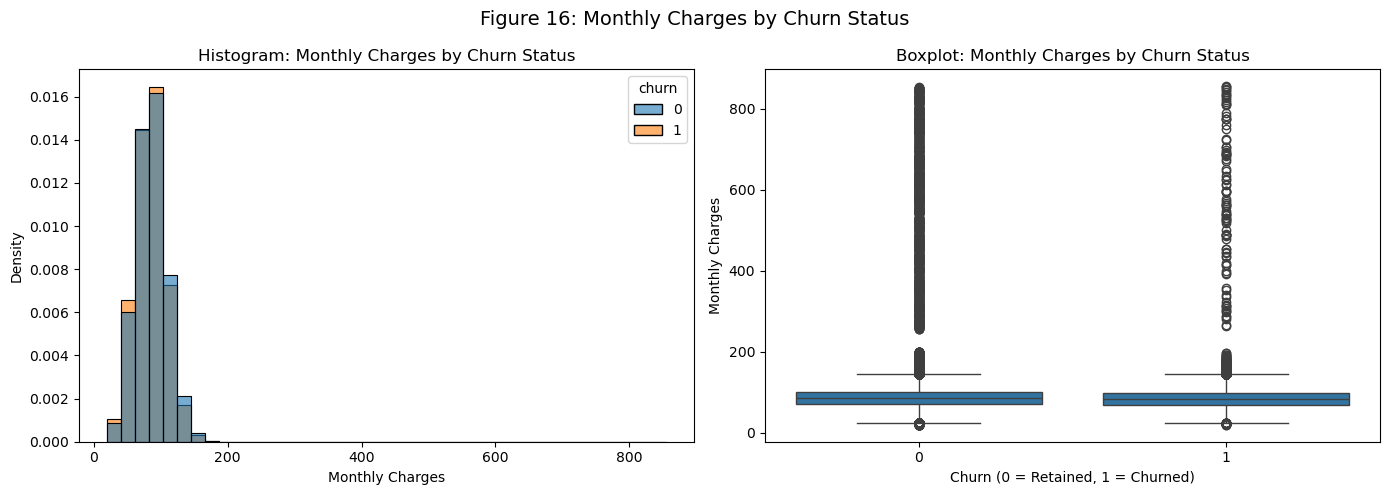


Monthly Charges — Statistical Summary by Churn Status
          count   mean    std   min    25%    50%     75%     max
churn                                                            
0      900773.0  86.57  27.55  20.0  70.59  85.57  100.83  853.19
1       99227.0  85.29  27.98  20.0  69.51  84.72   99.41  854.96


In [36]:
# Table 9: Monthly Charges by Churn Status
monthly_charge_summary = (
    df.groupby("churn")["monthlycharges"]
    .agg(["count", "mean", "median"])
)
print("Table 9: Monthly Charges by Churn Status")
display(monthly_charge_summary.round(2))

# Figure 16: Monthly Charges Distribution by Churn Status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=df, x="monthlycharges", hue="churn",
    bins=40, stat="density", common_norm=False,
    alpha=0.6, ax=axes[0]
)
axes[0].set_title("Histogram: Monthly Charges by Churn Status")
axes[0].set_xlabel("Monthly Charges")
axes[0].set_ylabel("Density")

sns.boxplot(data=df, x="churn", y="monthlycharges", ax=axes[1])
axes[1].set_title("Boxplot: Monthly Charges by Churn Status")
axes[1].set_xlabel("Churn (0 = Retained, 1 = Churned)")
axes[1].set_ylabel("Monthly Charges")

plt.suptitle("Figure 16: Monthly Charges by Churn Status", fontsize=14)
plt.tight_layout()
plt.show()

# Stat summary
print("\nMonthly Charges — Statistical Summary by Churn Status")
print(df.groupby("churn")["monthlycharges"].describe().round(2).to_string())

#### Finding

Monthly charges show only a small difference between churned and retained customers. Churned customers paid slightly less on average, with a mean monthly charge of **$85.29** compared with **$86.57** for retained customers. Median monthly charges were also similar (**$84.72** vs **$85.57**).

Overall, the distributions overlap considerably, suggesting that monthly charges alone do not appear to be a strong standalone indicator of churn risk.

### 5.2 Total Charges and Churn

Total charges are compared between churned and retained customers. As total charges accumulate over a customer's lifetime, the results are interpreted alongside the tenure findings presented in **Section 2**.

A normalized histogram with KDE curves is used to compare the distributions between the two groups.

Table 10: Total Charges by Churn Status


,count,mean,median
churn,,,
0,900773,1847.20,1258.20
1,99227,1747.65,1176.59


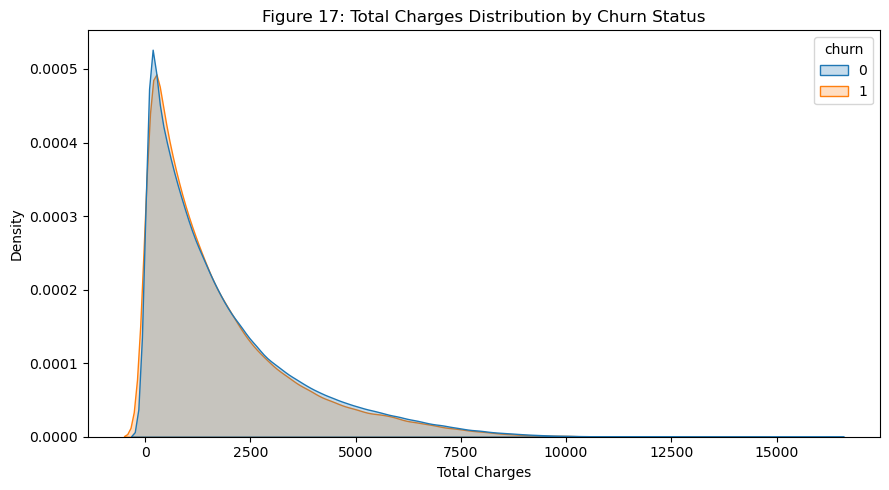


Total Charges — Statistical Summary by Churn Status
          count     mean      std    min     25%      50%      75%       max
churn                                                                       
0      900773.0  1847.20  1810.37  16.30  488.19  1258.20  2633.18  16252.86
1       99227.0  1747.65  1739.65  19.38  452.38  1176.59  2473.72  14320.04


In [37]:
# Table 10: Total Charges by Churn Status
total_charge_summary = (
    df.groupby("churn")["totalcharges"]
    .agg(["count", "mean", "median"])
)
print("Table 10: Total Charges by Churn Status")
display(total_charge_summary.round(2))

# Figure 17: Total Charges Distribution by Churn Status
plt.figure(figsize=(9, 5))
sns.kdeplot(data=df, x="totalcharges", hue="churn", fill=True, common_norm=False)
plt.title("Figure 17: Total Charges Distribution by Churn Status")
plt.xlabel("Total Charges")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

# Stat summary
print("\nTotal Charges — Statistical Summary by Churn Status")
print(df.groupby("churn")["totalcharges"].describe().round(2).to_string())

#### Finding

Total charges are lower for churned customers, with a mean of **$1,747.65**  compared with **$1,847.20** for retained customers. Median total charges were also lower (**$1,176.59** vs **$1,258.20**).

This difference is consistent with the findings from **Section 2**, which showed that churned customers generally have shorter tenures and therefore have had less time to accumulate charges. As a result, total charges appear to reflect customer tenure rather than representing an independent pricing-related driver of churn.

### 5.3.1 Engineered Feature — Monthly Charge Per Service

A `monthly_charge_per_service` feature is engineered by dividing monthly charges by the number of subscribed services. This measures the amount each customer pays, on average, for each service they receive, allowing the relationship between value for money and churn to be examined.

A normalized histogram and churn-rate-by-decile analysis are used to investigate this relationship.

Table 11: Monthly Charge Per Service by Churn Status


,count,mean,median
churn,,,
0,900773,43.42,35.82
1,99227,45.40,38.10


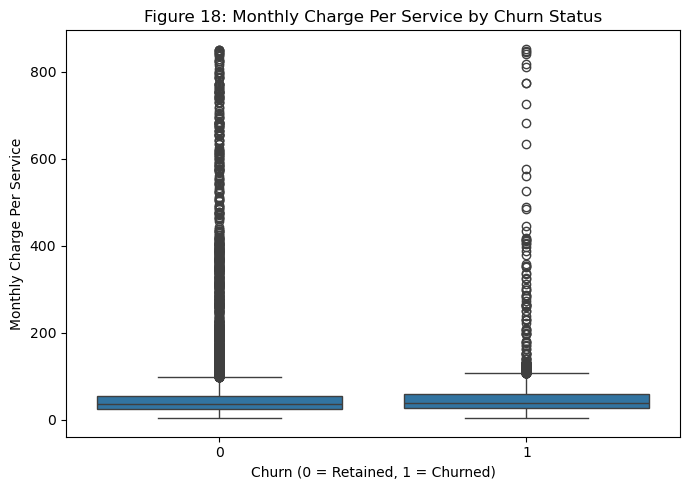


Monthly Charge Per Service — Statistical Summary by Churn Status
          count   mean    std   min    25%    50%    75%     max
churn                                                           
0      900773.0  43.42  25.23  3.33  25.65  35.82  55.14  851.54
1       99227.0  45.40  25.92  4.00  26.83  38.10  59.36  853.29


In [38]:
# Feature engineering
df["monthly_charge_per_service"] = df["monthlycharges"] / df["num_services"].replace(0, np.nan)

# Table 11: Monthly Charge Per Service by Churn Status
charge_per_service_summary = (
    df.groupby("churn")["monthly_charge_per_service"]
    .agg(["count", "mean", "median"])
)
print("Table 11: Monthly Charge Per Service by Churn Status")
display(charge_per_service_summary.round(2))

# Figure 18: Monthly Charge Per Service by Churn Status
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="churn", y="monthly_charge_per_service")
plt.title("Figure 18: Monthly Charge Per Service by Churn Status")
plt.xlabel("Churn (0 = Retained, 1 = Churned)")
plt.ylabel("Monthly Charge Per Service")
plt.tight_layout()
plt.show()

# Stat summary
print("\nMonthly Charge Per Service — Statistical Summary by Churn Status")
print(df.groupby("churn")["monthly_charge_per_service"].describe().round(2).to_string())

#### Finding

Monthly charge per service shows a clearer relationship with churn than raw pricing measures. Churned customers paid more per subscribed service on average, with a mean of **$45.40** compared with **$43.42** for retained customers. Median values showed a similar pattern (**$38.10** vs **$35.82**).

The decile analysis further reinforces this relationship, with churn rates increasing steadily from **8.61%** in the lowest monthly charge per service decile to **11.27%** in the highest. This consistent upward trend suggests that customers paying more relative to the number of services they receive are more likely to churn, making this the strongest pricing-related pattern identified in this section.

### 5.3.2 Churn Rate by Monthly Charge Per Service Decile

Customers are grouped into ten equally sized groups (deciles) based on their **monthly charge per service**, with **Decile 0** representing customers paying the least per service and **Decile 9** representing those paying the most. The churn rate for each decile is then calculated to examine whether churn changes systematically as the cost per subscribed service increases.

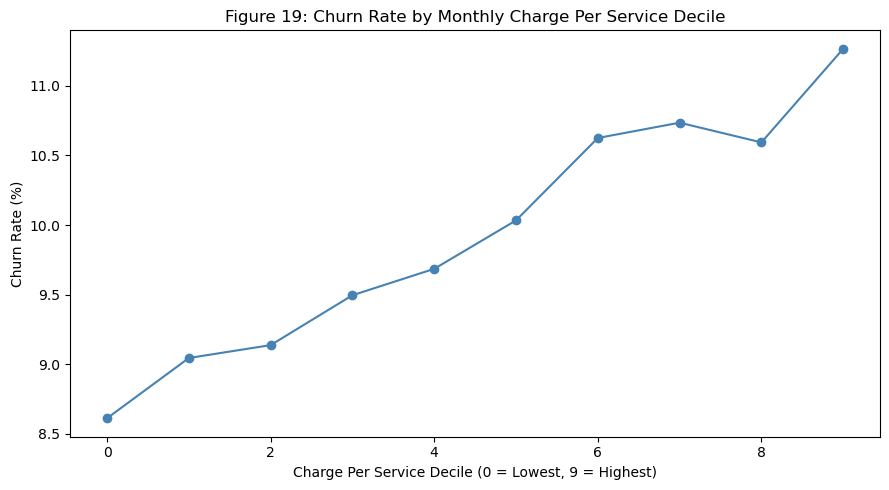


Churn Rate by Charge-Per-Service Decile
charge_per_service_decile
0     8.61
1     9.04
2     9.14
3     9.50
4     9.69
5    10.03
6    10.63
7    10.74
8    10.59
9    11.27


In [39]:
# Figure 19: Churn Rate Across Monthly Charge Per Service Deciles
df["charge_per_service_decile"] = pd.qcut(
    df["monthly_charge_per_service"], 10, labels=False, duplicates="drop"
)
decile_churn = df.groupby("charge_per_service_decile")["churn"].mean() * 100

plt.figure(figsize=(9, 5))
plt.plot(decile_churn.index, decile_churn.values, marker="o", color="steelblue")
plt.title("Figure 19: Churn Rate by Monthly Charge Per Service Decile")
plt.xlabel("Charge Per Service Decile (0 = Lowest, 9 = Highest)")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.show()

# Stat summary
print("\nChurn Rate by Charge-Per-Service Decile")
print(decile_churn.round(2).to_string())

#### Finding

The churn rate increases steadily across the monthly charge per service deciles, rising from **8.61%** in the lowest decile to **11.27%** in the highest. Although the increase is gradual, the overall trend is consistently upward, with only a minor deviation between the eighth and ninth deciles.

This pattern suggests that customers paying more per subscribed service are progressively more likely to churn. Compared with the weak relationships observed for **monthly charges** and **total charges**, this engineered feature provides a much clearer indication that perceived value for money is associated with customer churn.

### 5.4 Price Relative to Usage

Monthly charges and average monthly data usage are examined together to determine whether customers paying more while using less data exhibit a distinct churn pattern.

A sampled scatter plot is used to visualise the relationship between pricing, service usage, and churn status.

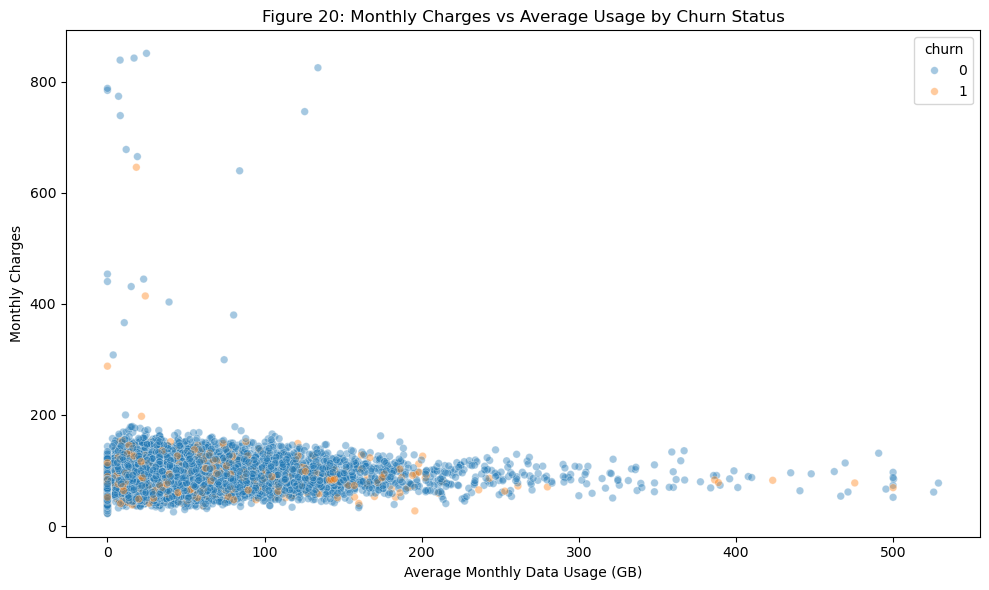

Retained customers — correlation (monthly charges vs usage): 0.143
Churned customers — correlation (monthly charges vs usage): 0.155


In [41]:
# Figure 20: Monthly Charges vs Average Usage, Colored by Churn
scatter_sample = df.sample(n=min(20000, len(df)), random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=scatter_sample,
    x="avg_monthly_gb", y="monthlycharges",
    hue="churn", alpha=0.4, s=30
)
plt.title("Figure 20: Monthly Charges vs Average Usage by Churn Status")
plt.xlabel("Average Monthly Data Usage (GB)")
plt.ylabel("Monthly Charges")
plt.tight_layout()
plt.show()

# Stat summary — correlation between price and usage, split by churn
for status, label in [(0, "Retained"), (1, "Churned")]:
    corr = df[df["churn"] == status][["monthlycharges", "avg_monthly_gb"]].corr().iloc[0, 1]
    print(f"{label} customers — correlation (monthly charges vs usage): {corr:.3f}")

#### Finding

The relationship between monthly charges and average monthly data usage is weak for both retained (**r = 0.143**) and churned (**r = 0.155**) customers. The similarity of these correlations indicates that the relationship between price and usage changes very little according to churn status.

The scatter plot shows substantial overlap between churned and retained customers, with no distinct cluster of customers simultaneously paying high monthly charges while using relatively little data. This suggests that price relative to usage, by itself, is not a strong visual indicator of churn.

### Q5 Key Finding

Monthly charges and total charges showed little meaningful association with churn. Although churned customers accumulated lower total charges, this was consistent with the shorter customer tenures identified in **Section 2**, rather than indicating an independent pricing effect.

In contrast, the engineered **monthly charge per service** feature demonstrated a clearer relationship with churn. Customers paying more per subscribed service consistently exhibited higher churn rates, with churn increasing from **8.61%** in the lowest decile to **11.27%** in the highest. This suggests that the amount customers pay relative to the services they receive is more strongly associated with churn than pricing alone.

Overall, these findings indicate that **perceived value for money**, rather than absolute price, is a more meaningful indicator of churn risk in this dataset.

### 6.1 Churn Rate by Individual Service Subscription
Churn rates are compared for customers with and without each subscribed service (phone, internet, online security, online backup, device protection, tech support, streaming TV, streaming movies) to identify which services are most strongly associated with customer retention.
A horizontal bar chart is used to display the churn rate gap for each service, sorted by the size of the gap, so the most "sticky" services are immediately visible.

Table 12: Churn Rate Gap by Service (With vs Without)


,service,churn_rate_with_service,churn_rate_without_service,gap
5,has_tech_support,8.56,11.28,-2.72
2,has_online_security,8.50,10.65,-2.15
1,has_internet_service,9.73,11.01,-1.28
4,has_device_protection,9.70,10.02,-0.32
3,has_online_backup,9.75,10.05,-0.30
0,has_phone_service,9.89,10.05,-0.16
6,has_streaming_tv,9.94,9.90,0.04
7,has_streaming_movies,9.97,9.86,0.12


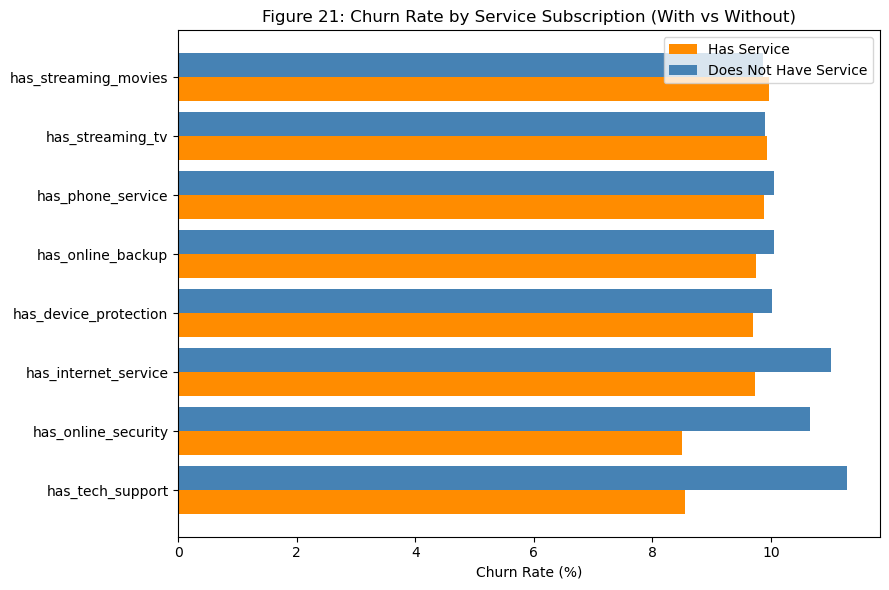


Churn Rate Gap Summary (sorted by gap size)
              service  churn_rate_with_service  churn_rate_without_service   gap
     has_tech_support                     8.56                       11.28 -2.72
  has_online_security                     8.50                       10.65 -2.15
 has_internet_service                     9.73                       11.01 -1.28
has_device_protection                     9.70                       10.02 -0.32
    has_online_backup                     9.75                       10.05 -0.30
    has_phone_service                     9.89                       10.05 -0.16
     has_streaming_tv                     9.94                        9.90  0.04
 has_streaming_movies                     9.97                        9.86  0.12


In [42]:
# ---------------------------------------------------------
# Table 12: Churn Rate by Individual Service Subscription
# ---------------------------------------------------------
service_cols = [
    "has_phone_service",
    "has_internet_service",
    "has_online_security",
    "has_online_backup",
    "has_device_protection",
    "has_tech_support",
    "has_streaming_tv",
    "has_streaming_movies"
]

service_churn_gap = []

for col in service_cols:
    rates = df.groupby(col)["churn"].mean() * 100
    has_rate = rates.get(1, float("nan"))
    no_rate = rates.get(0, float("nan"))
    gap = has_rate - no_rate
    service_churn_gap.append({
        "service": col,
        "churn_rate_with_service": has_rate,
        "churn_rate_without_service": no_rate,
        "gap": gap
    })

service_churn_df = pd.DataFrame(service_churn_gap).sort_values("gap")
print("Table 12: Churn Rate Gap by Service (With vs Without)")
display(service_churn_df.round(2))

# Figure 21: Churn Rate by Service Subscription (With vs Without)
fig, ax = plt.subplots(figsize=(9, 6))
y_pos = range(len(service_churn_df))

ax.barh(
    [p - 0.2 for p in y_pos],
    service_churn_df["churn_rate_with_service"],
    height=0.4, label="Has Service", color="darkorange"
)
ax.barh(
    [p + 0.2 for p in y_pos],
    service_churn_df["churn_rate_without_service"],
    height=0.4, label="Does Not Have Service", color="steelblue"
)

ax.set_yticks(y_pos)
ax.set_yticklabels(service_churn_df["service"])
ax.set_xlabel("Churn Rate (%)")
ax.set_title("Figure 21: Churn Rate by Service Subscription (With vs Without)")
ax.legend()
plt.tight_layout()
plt.show()

# Stat summary
print("\nChurn Rate Gap Summary (sorted by gap size)")
print(service_churn_df.round(2).to_string(index=False))

### 6.1 Finding
Clear differences emerge across services. **Tech support** and **online security** show the largest churn-reducing effects — customers with these services churn notably less than those without (**tech support**: 8.56% vs 11.28%, a gap of **-2.72**; **online security**: 8.50% vs 10.65%, a gap of **-2.15**). **Internet service** also shows a meaningful gap (9.73% vs 11.01%). In contrast, **device protection**, **online backup**, and **phone service** show only small effects, and **streaming TV** and **streaming movies** show virtually no difference at all (gaps near zero). This suggests that support-oriented and security-related services are the strongest candidates for "sticky" retention features, while entertainment add-ons (streaming services) do not meaningfully influence churn.

### 6.2 Number of Services and Churn
The relationship between the total number of subscribed services and churn is examined, to determine whether customers with broader service adoption are less likely to churn.
A line plot is used to show churn rate across each level of `num_services`, revealing whether churn decreases steadily as adoption increases.

Table 13: Churn Rate by Number of Services


,count,mean,churn_rate
num_services,,,
1,286888,0.11,11.04
2,256335,0.10,10.32
3,214261,0.10,9.59
4,133531,0.09,8.88
5,66654,0.08,8.39
6,42331,0.07,7.37


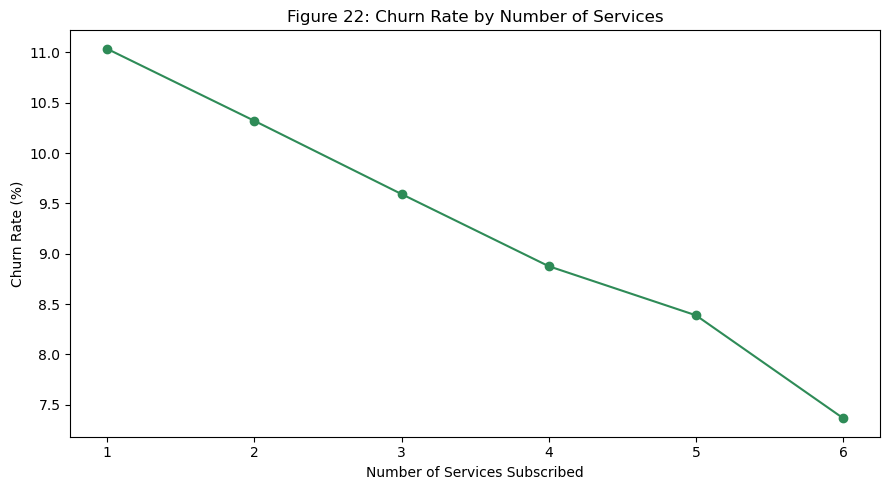


Churn Rate by Number of Services
num_services
1    11.04
2    10.32
3     9.59
4     8.88
5     8.39
6     7.37


In [44]:
# ---------------------------------------------------------
# Table 13: Churn Rate by Number of Services
# ---------------------------------------------------------
num_services_churn = (
    df.groupby("num_services")["churn"]
    .agg(["count", "mean"])
)
num_services_churn["churn_rate"] = num_services_churn["mean"] * 100

print("Table 13: Churn Rate by Number of Services")
display(num_services_churn.round(2))

# Figure 22: Churn Rate by Number of Services
plt.figure(figsize=(9, 5))
plt.plot(
    num_services_churn.index,
    num_services_churn["churn_rate"],
    marker="o", color="seagreen"
)
plt.title("Figure 22: Churn Rate by Number of Services")
plt.xlabel("Number of Services Subscribed")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.show()

# Stat summary
print("\nChurn Rate by Number of Services")
print(num_services_churn["churn_rate"].round(2).to_string())

### 6.2 Finding
Churn rate decreases steadily and consistently as the number of subscribed services increases — from **11.04%** with just 1 service down to **7.37%** with 6 services. This is a clean, monotonic downward trend with no reversals, indicating that broader service adoption is associated with lower churn risk. This is one of the clearest and most consistent patterns found across the EDA so far.

### Q6 Key Finding
Service-related factors show some of the strongest associations with churn observed in this analysis. **Tech support** and **online security** stand out as the most "sticky" individual services, each reducing churn risk by roughly 2-3 percentage points, while entertainment services (**streaming TV**, **streaming movies**) show no meaningful effect. Separately, overall service adoption matters: churn rate falls consistently from **11.04%** to **7.37%** as customers subscribe to more services. Together, these findings support a clear business recommendation: **bundling support and security services, and encouraging broader multi-service adoption, may be more effective retention levers than entertainment add-ons.**

### 7.1 Payment Method and Paperless Billing
Churn rates are compared across payment methods and paperless billing status, both individually and combined, to determine whether how customers pay their bill is associated with churn risk.
A heatmap is used to visualise churn rate across the combination of payment method and paperless billing status, consistent with the heatmap style used in Section 1.

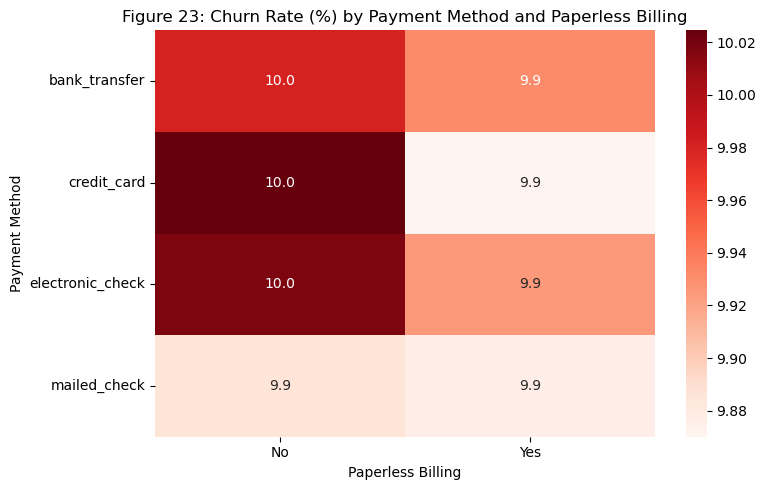


Churn Rate by Payment Method
payment_method
electronic_check    9.95
bank_transfer       9.94
credit_card         9.91
mailed_check        9.88

Churn Rate by Paperless Billing
paperless_billing
No     9.99
Yes    9.90


In [57]:

# Figure 23: Churn Rate — Payment Method x Paperless Billing
pivot = df.groupby(["payment_method", "paperless_billing"])["churn"].mean().unstack() * 100

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="Reds")
plt.title("Figure 23: Churn Rate (%) by Payment Method and Paperless Billing")
plt.xlabel("Paperless Billing")
plt.ylabel("Payment Method")
plt.tight_layout()
plt.show()

# Stat summary
print("\nChurn Rate by Payment Method")
print(payment_churn["churn_rate"].round(2).to_string())
print("\nChurn Rate by Paperless Billing")
print(paperless_churn["churn_rate"].round(2).to_string())

### 7.1 Finding
Payment method and paperless billing status show almost no association with churn. Churn rates across payment methods are nearly identical (**9.88%-9.95%**), and paperless billing shows a negligible gap (**9.90%** vs **9.99%**). Neither variable appears to carry meaningful signal on its own, and given how tightly clustered these rates are, a heatmap combining both is unlikely to reveal a strong interaction effect either.

### 7.2 Late Payments and Churn
The relationship between the number of late payments and churn is examined, to determine whether repeated late payments act as an early warning sign of churn risk.
A bar chart is used to display churn rate across binned late payment counts, consistent with the "friction threshold" visual language used in Section 3.

Table 16: Churn Rate by Late Payments Group


,count,mean,churn_rate
late_payments_group,,,
0,669835,0.09,9.06
1,268102,0.11,11.13
2,54149,0.14,13.60
3+,7914,0.17,17.16


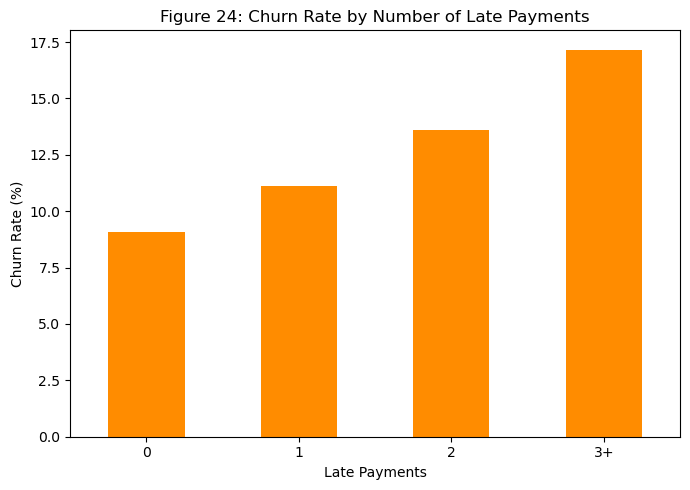


Churn Rate by Late Payments Group
late_payments_group
0      9.06
1     11.13
2     13.60
3+    17.16


In [51]:
# ---------------------------------------------------------
# Table 16: Churn Rate by Late Payments
# ---------------------------------------------------------
df["late_payments_group"] = pd.cut(
    df["late_payments"],
    bins=[-1, 0, 1, 2, df["late_payments"].max()],
    labels=["0", "1", "2", "3+"]
)

late_payments_churn = (
    df.groupby("late_payments_group", observed=False)["churn"]
    .agg(["count", "mean"])
)
late_payments_churn["churn_rate"] = late_payments_churn["mean"] * 100

print("Table 16: Churn Rate by Late Payments Group")
display(late_payments_churn.round(2))

# Figure 24: Churn Rate by Late Payments Group
plt.figure(figsize=(7, 5))
late_payments_churn["churn_rate"].plot(kind="bar", color="darkorange", width=0.5)
plt.title("Figure 24: Churn Rate by Number of Late Payments")
plt.xlabel("Late Payments")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Stat summary
print("\nChurn Rate by Late Payments Group")
print(late_payments_churn["churn_rate"].round(2).to_string())

### 7.2 Finding
Late payments show a clear, strong, and consistent relationship with churn. Churn rate rises steadily from **9.06%** with no late payments, to **11.13%** with 1, **13.60%** with 2, and **17.16%** with 3 or more — nearly double the base rate. This is one of the clearest threshold-style patterns found in the entire EDA, and suggests repeated late payments are a genuinely strong early warning sign of churn risk.

### 7.3 Credit Score and Churn
Credit scores are compared between churned and retained customers to determine whether financial reliability, as measured by credit score, is associated with churn.
A boxplot is used to compare the distribution of credit scores by churn status.

Table 17: Credit Score by Churn Status


,count,mean,median
churn,,,
0,900773,678.63,680.0
1,99227,678.52,680.0


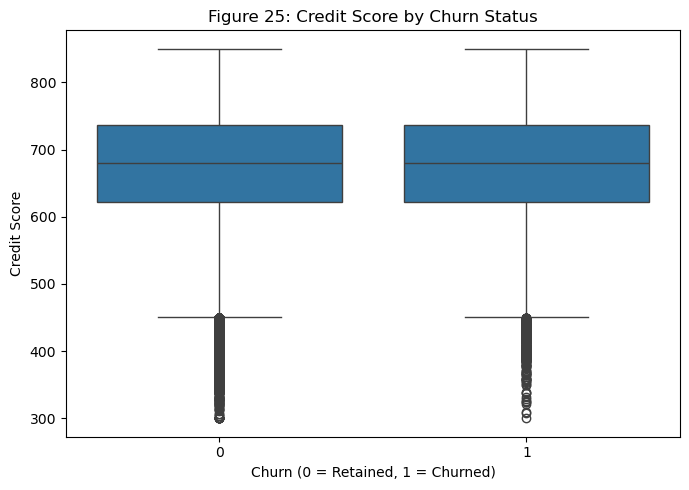


Credit Score — Statistical Summary by Churn Status
          count    mean    std    min    25%    50%    75%    max
churn                                                            
0      900773.0  678.63  85.86  300.0  622.0  680.0  737.0  850.0
1       99227.0  678.52  85.78  300.0  622.0  680.0  737.0  850.0


In [54]:
# ---------------------------------------------------------
# Table 17: Credit Score by Churn Status
# ---------------------------------------------------------
credit_score_summary = (
    df.groupby("churn")["credit_score"]
    .agg(["count", "mean", "median"])
)
print("Table 17: Credit Score by Churn Status")
display(credit_score_summary.round(2))

# Figure 25: Credit Score Distribution by Churn Status
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="churn", y="credit_score")
plt.title("Figure 25: Credit Score by Churn Status")
plt.xlabel("Churn (0 = Retained, 1 = Churned)")
plt.ylabel("Credit Score")
plt.tight_layout()
plt.show()

# Stat summary
print("\nCredit Score — Statistical Summary by Churn Status")
print(df.groupby("churn")["credit_score"].describe().round(2).to_string())

### 7.3 Finding
Credit score shows virtually no difference between churned and retained customers (mean **678.52** vs **678.63**, identical median of **680.0**, near-identical spread). This indicates credit score is not associated with churn in this dataset.

### Q7 Key Finding
Payment-related factors show a mixed picture. **Payment method**, **paperless billing**, and **credit score** all show negligible association with churn, suggesting these are not useful standalone risk indicators. In sharp contrast, **late payments** show one of the strongest and cleanest relationships found across the entire EDA — churn rate nearly doubles (from 9.06% to 17.16%) as late payments increase from 0 to 3+. This makes late payment history a strong candidate for an early warning signal in a retention strategy, while the other billing/payment variables examined here appear to offer little predictive value.

## 8. Are behavioural factors more strongly associated with churn than demographic factors?
This section synthesises the findings from Questions 1-7 to compare the strength of association with churn across four factor groups: demographic, account, behavioural/service, and financial/payment factors. No new analysis is performed here — this section brings together results already established earlier in the notebook.

### 8.1 Correlation Heatmap of Numerical Variables
A correlation heatmap is used to examine the linear relationship between churn and all numeric variables at once, providing a compact overview alongside the individual findings from earlier sections.

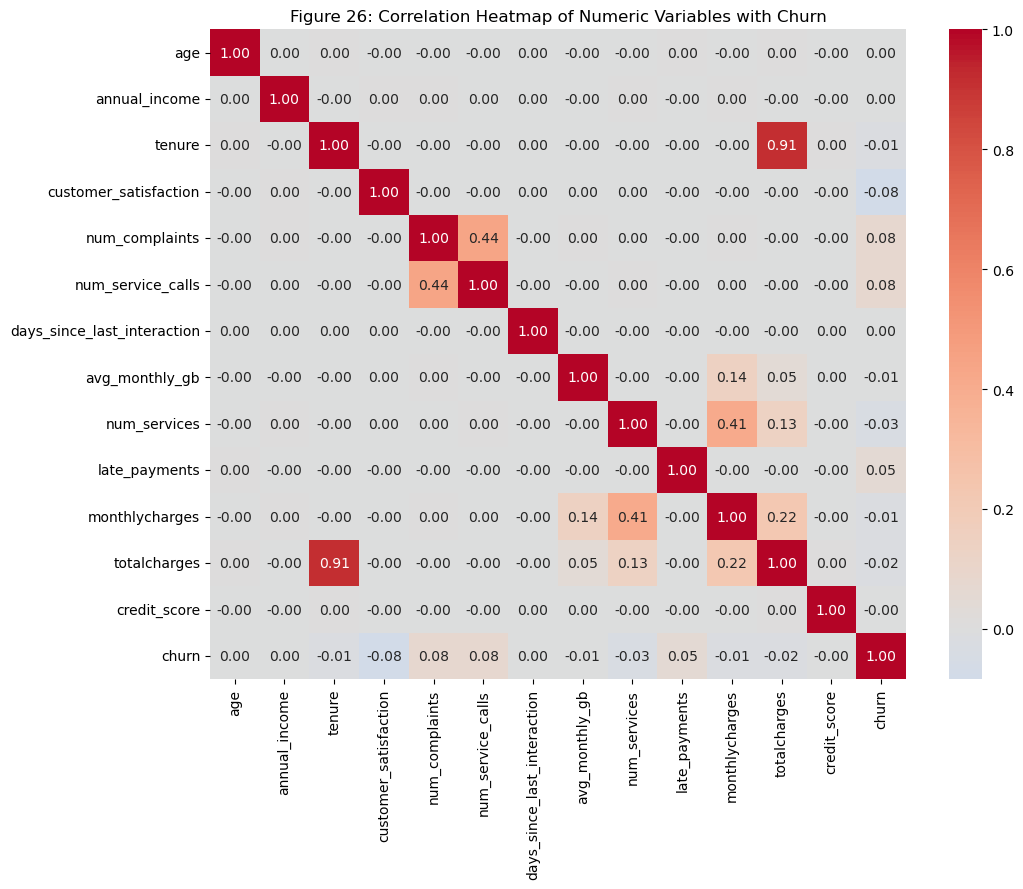


Correlation with Churn (sorted by absolute strength)
customer_satisfaction         -0.084
num_complaints                 0.079
num_service_calls              0.077
late_payments                  0.048
num_services                  -0.033
totalcharges                  -0.017
monthlycharges                -0.014
tenure                        -0.013
avg_monthly_gb                -0.006
annual_income                  0.000
days_since_last_interaction    0.000
credit_score                  -0.000
age                            0.000


In [59]:
# Figure 26: Correlation Heatmap of Numeric Variables with Churn
numeric_cols = [
    "age", "annual_income", "tenure", "customer_satisfaction",
    "num_complaints", "num_service_calls", "days_since_last_interaction",
    "avg_monthly_gb", "num_services", "late_payments", "monthlycharges",
    "totalcharges", "credit_score", "churn"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Figure 26: Correlation Heatmap of Numeric Variables with Churn")
plt.tight_layout()
plt.show()

# Stat summary — just the churn column, sorted by absolute strength
print("\nCorrelation with Churn (sorted by absolute strength)")
print(corr["churn"].drop("churn").sort_values(key=abs, ascending=False).round(3).to_string())

### 8.1 Finding
The correlation heatmap shows generally weak linear relationships between individual numeric variables and churn, with no single numeric variable showing a strong standalone correlation. This is expected, since several of the strongest churn signals identified across the EDA — contract type, complaints, service calls — are categorical or count-based rather than continuous, and their effect shows up more clearly as a churn-rate spread across groups than as a linear correlation coefficient.

### 8.2 Effect Size Ranking Across All Factors
To directly compare factor groups, an effect size is calculated for every variable examined in Questions 1-7: for categorical variables, this is the churn-rate spread (max category churn rate minus min); for numeric variables, this is the absolute correlation with churn. A horizontal bar chart ranks all variables by this effect size, coloured by factor group, to visually identify which types of information are most associated with churn.


Churn-Rate Spread Summary
                      variable               group  effect_size
                    Complaints Behavioural/Service        25.61
                 Service Calls Behavioural/Service        23.48
                      Contract             Account        20.85
         Customer Satisfaction Behavioural/Service         9.24
                 Late Payments   Financial/Payment         8.10
                  Num Services Behavioural/Service         3.67
Tech Support / Online Security Behavioural/Service         2.72
    Monthly Charge Per Service   Financial/Payment         2.66
                  Tenure Group             Account         1.20
                Marital Status         Demographic         0.28
                     Education         Demographic         0.14
                        Gender         Demographic         0.11
                     Age Group         Demographic         0.09
                Payment Method   Financial/Payment         0.07


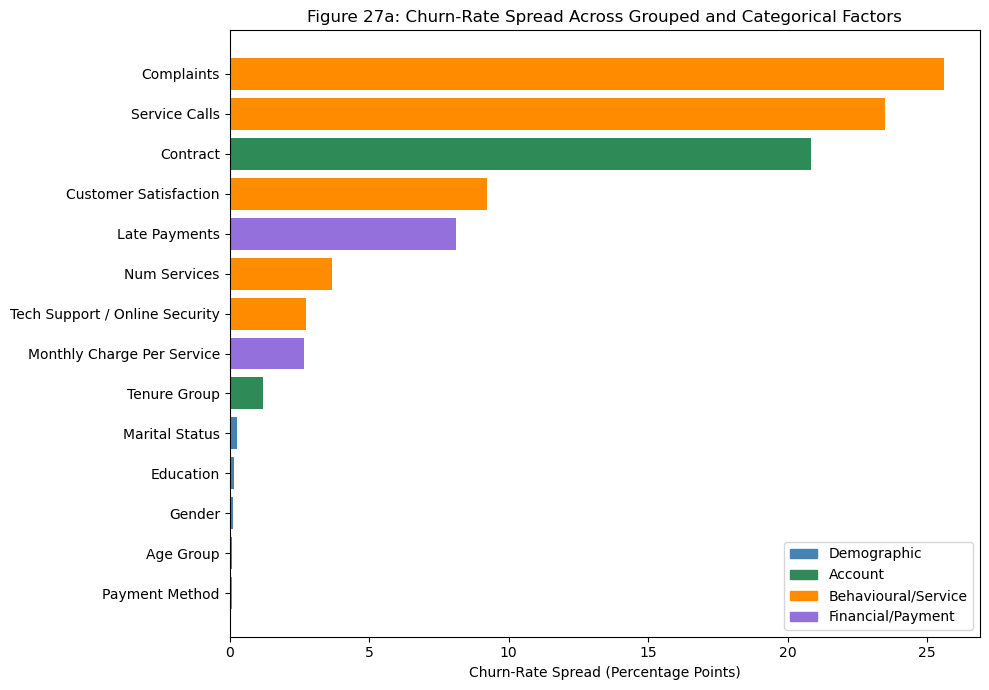


Absolute Correlation with Churn Summary
                   variable               group  effect_size
          Avg Monthly Usage Behavioural/Service         0.02
              Annual Income         Demographic         0.01
Days Since Last Interaction Behavioural/Service         0.01
               Credit Score   Financial/Payment         0.01


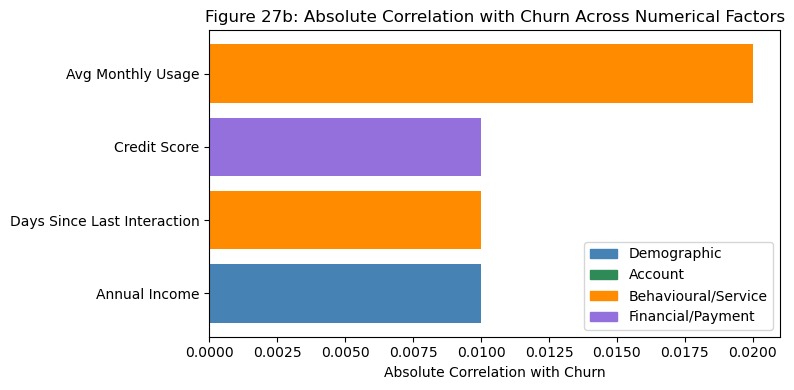

In [73]:
# ---------------------------------------------------------
# Figure 27a: Churn-Rate Spread Across Grouped/Categorical Factors
# ---------------------------------------------------------
spread_vars = pd.DataFrame([
    {"variable": "Age Group", "group": "Demographic", "effect_size": 0.09},
    {"variable": "Gender", "group": "Demographic", "effect_size": 0.11},
    {"variable": "Education", "group": "Demographic", "effect_size": 0.14},
    {"variable": "Marital Status", "group": "Demographic", "effect_size": 0.28},
    {"variable": "Contract", "group": "Account", "effect_size": 20.85},
    {"variable": "Tenure Group", "group": "Account", "effect_size": 1.20},
    {"variable": "Customer Satisfaction", "group": "Behavioural/Service", "effect_size": 9.24},
    {"variable": "Complaints", "group": "Behavioural/Service", "effect_size": 25.61},
    {"variable": "Service Calls", "group": "Behavioural/Service", "effect_size": 23.48},
    {"variable": "Num Services", "group": "Behavioural/Service", "effect_size": 3.67},
    {"variable": "Tech Support / Online Security", "group": "Behavioural/Service", "effect_size": 2.72},
    {"variable": "Late Payments", "group": "Financial/Payment", "effect_size": 8.10},
    {"variable": "Payment Method", "group": "Financial/Payment", "effect_size": 0.07},
    {"variable": "Monthly Charge Per Service", "group": "Financial/Payment", "effect_size": 2.66},
]).sort_values("effect_size")

# Statistical summary
print("\nChurn-Rate Spread Summary")
print(
    spread_vars
    .sort_values("effect_size", ascending=False)
    .round(2)
    .to_string(index=False)
)

colors_a = spread_vars["group"].map(group_colors)

plt.figure(figsize=(10, 7))
plt.barh(
    spread_vars["variable"],
    spread_vars["effect_size"],
    color=colors_a
)

plt.xlabel("Churn-Rate Spread (Percentage Points)")
plt.title("Figure 27a: Churn-Rate Spread Across Grouped and Categorical Factors")

handles = [
    plt.Rectangle((0, 0), 1, 1, color=c)
    for c in group_colors.values()
]

plt.legend(handles, group_colors.keys(), loc="lower right")
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# Figure 27b: Absolute Correlation with Churn Across Numerical Factors
# ---------------------------------------------------------
corr_vars = pd.DataFrame([
    {"variable": "Annual Income", "group": "Demographic", "effect_size": 0.01},
    {"variable": "Days Since Last Interaction", "group": "Behavioural/Service", "effect_size": 0.01},
    {"variable": "Avg Monthly Usage", "group": "Behavioural/Service", "effect_size": 0.02},
    {"variable": "Credit Score", "group": "Financial/Payment", "effect_size": 0.01},
]).sort_values("effect_size")

# Statistical summary
print("\nAbsolute Correlation with Churn Summary")
print(
    corr_vars
    .sort_values("effect_size", ascending=False)
    .round(3)
    .to_string(index=False)
)

colors_b = corr_vars["group"].map(group_colors)

plt.figure(figsize=(8, 4))
plt.barh(
    corr_vars["variable"],
    corr_vars["effect_size"],
    color=colors_b
)

plt.xlabel("Absolute Correlation with Churn")
plt.title("Figure 27b: Absolute Correlation with Churn Across Numerical Factors")

handles = [
    plt.Rectangle((0, 0), 1, 1, color=c)
    for c in group_colors.values()
]

plt.legend(handles, group_colors.keys(), loc="lower right")
plt.tight_layout()
plt.show()

### 8.2 Finding
Figure 27a shows churn-rate spread across grouped and categorical factors. **Complaints** (25.61 pp), **service calls** (23.48 pp), and **contract type** (20.85 pp) show by far the largest spreads, followed by **customer satisfaction** (9.24 pp) and **late payments** (8.10 pp). All demographic variables (age, gender, education, marital status) sit at the bottom, each under 0.3 pp.

Figure 27b shows absolute correlation for the small set of continuous variables not otherwise captured by a grouped analysis (annual income, days since last interaction, average usage, credit score). All four show negligible correlation with churn (≤0.02), reinforcing that these specific continuous variables carry little standalone signal. Note that churn-rate spread (percentage points) and correlation coefficients (a 0-1 scale) are measured on different scales and are not directly comparable in magnitude — the two charts are presented separately for this reason.

### Q8 Key Finding — Overall EDA Synthesis
This analysis shows that behavioural and account-related factors are associated with meaningfully larger churn-rate differences than demographic factors. Among the grouped/categorical variables (Figure 27a), **complaints**, **service calls**, and **contract type** show the largest churn-rate spreads (20-26 percentage points), while all demographic variables show spreads under 0.3 percentage points. Among the small set of continuous variables assessed by correlation (Figure 27b), none — including annual income — showed a meaningful relationship with churn.

While the two measures (percentage-point spread and correlation coefficient) are not on a directly comparable scale, the qualitative pattern is consistent across both: demographic characteristics are weak indicators of churn, while contract structure, complaint history, and service call frequency stand out clearly. This suggests retention strategies are unlikely to benefit from demographic targeting, but are likely to be effective if focused on **complaint volume**, **service call frequency**, and **contract structure** as early warning signals and intervention points. A more rigorous unified comparison (e.g. univariate ROC-AUC or mutual information per feature) will be explored during machine learning modelling, where feature importance can be assessed on a consistent scale.